In [1]:
!rm -rf prism-xai

In [2]:
!git clone https://github.com/shriyanssahoo/prism-xai.git

Cloning into 'prism-xai'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 174 (delta 3), reused 173 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 13.48 MiB | 16.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
cd prism-xai

/content/prism-xai


In [4]:
!pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam>=1.4.8 (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam>=1.4.8


In [5]:
from src.model_utils import load_model, load_image, get_vgg16_last_conv_layer, ActivationExtractor
from src.prism import compute_prism
import torch, glob

model = load_model("vgg16")
layer = get_vgg16_last_conv_layer(model)
extractor = ActivationExtractor(model, layer)

paths = glob.glob("data/raw/timber_wolf/*")[:2] + glob.glob("data/raw/coyote/*")[:1]
print(paths)  # sanity check paths are found

tensors = [load_image(p)[0] for p in paths]
batch = torch.stack(tensors).to(next(model.parameters()).device)

with torch.no_grad():
    model(batch)

prism_maps, variances, all_var = compute_prism(extractor.activations)
print("PRISM map shape:", prism_maps.shape)
print("Top-3 PC variance:", variances, "sum:", variances.sum())

['data/raw/timber_wolf/n02114548_10024.JPEG', 'data/raw/timber_wolf/n02114548_10093.JPEG', 'data/raw/coyote/n02114855_10035.JPEG']
PRISM map shape: (3, 3, 14, 14)
Top-3 PC variance: [0.25281637 0.14438103 0.07728306] sum: 0.47448046021776147


In [6]:
from src.model_utils import load_model, load_image, get_vgg16_last_conv_layer, ActivationExtractor
from src.prism import compute_prism
print("Imports OK")

Imports OK


In [7]:
from src.model_utils import load_model, load_image, get_vgg16_last_conv_layer, ActivationExtractor
from src.prism import compute_prism
import torch, glob

model = load_model("vgg16")
layer = get_vgg16_last_conv_layer(model)
extractor = ActivationExtractor(model, layer)

paths = glob.glob("data/raw/timber_wolf/*")[:2] + glob.glob("data/raw/coyote/*")[:1]
print(paths)  # sanity check paths are found

tensors = [load_image(p)[0] for p in paths]
batch = torch.stack(tensors).to(next(model.parameters()).device)

with torch.no_grad():
    model(batch)

prism_maps, variances, all_var = compute_prism(extractor.activations)
print("PRISM map shape:", prism_maps.shape)
print("Top-3 PC variance:", variances, "sum:", variances.sum())

['data/raw/timber_wolf/n02114548_10024.JPEG', 'data/raw/timber_wolf/n02114548_10093.JPEG', 'data/raw/coyote/n02114855_10035.JPEG']
PRISM map shape: (3, 3, 14, 14)
Top-3 PC variance: [0.25281637 0.14438103 0.07728306] sum: 0.47448046021776147


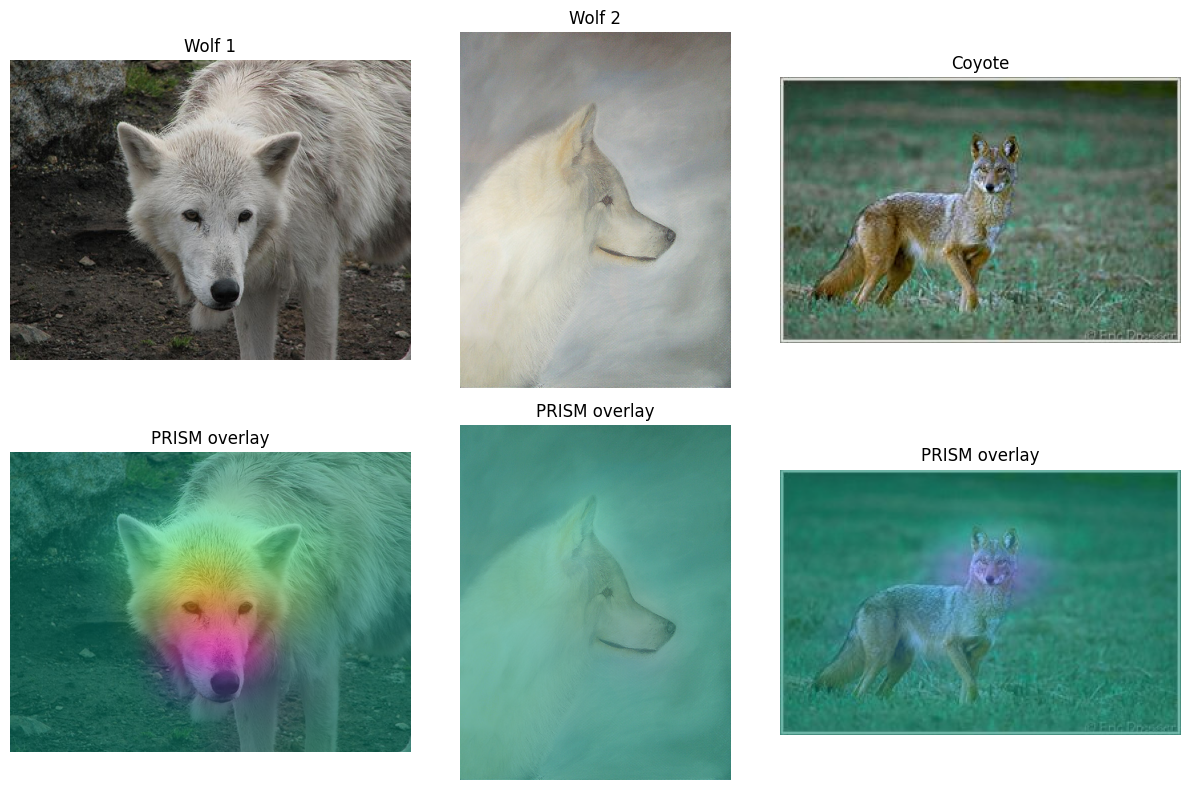

In [8]:
from src.visualize import plot_prism_batch

# get the original (non-normalized) PIL images too
originals = [load_image(p)[1] for p in paths]

plot_prism_batch(originals, prism_maps, titles=["Wolf 1", "Wolf 2", "Coyote"])